# Generating submission ready results with log + log model

In [1]:
#Fitting logistic regression to class2
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from pathlib import Path


# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

from src.logistic_regression import plot_sigmoid

data_dir = Path('../data')
output_dir = Path('../outputs')

## Reading in the data

In [2]:
#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y2_train, y4_train = ppm.split_xy(train_df)

#All data 
ev_ne_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = ev_ne_scaler.fit_transform(X_train)

#Event data only
event_mask_train = y4_train != 'nonevent'
X_train_events = X_train[event_mask_train]
y_train_events = y4_train[event_mask_train]
y_train_events = y_train_events.replace({'Ia': 'Ib'})
event_scaler = StandardScaler().set_output(transform="pandas")
X_train_events_scaled = event_scaler.fit_transform(X_train_events)


#Final test data
X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
# For event/nonenent classification
X_test_final_scaled = ev_ne_scaler.transform(X_test_final)
#For event type I/II classification
X_test_final_ev_scale = event_scaler.transform(X_test_final)

#PCA 
PCA_ev_ne = PCA(n_components=27)
PCA_ev_ne.fit(pd.concat([X_train_scaled, X_test_final_scaled]))
X_train_ev_ne_pca = PCA_ev_ne.transform(X_train_scaled)
X_test_final_ev_ne_pca = PCA_ev_ne.transform(X_test_final_scaled)

PCA_events = PCA(n_components=6)
PCA_events.fit(pd.concat([X_train_events_scaled, X_test_final_ev_scale]))
X_train_events_pca = PCA_events.transform(X_train_events_scaled)
X_test_final_events_pca = PCA_events.transform(X_test_final_ev_scale)


In [3]:
y4_train.value_counts()

class4
nonevent    225
II          117
Ib           82
Ia           26
Name: count, dtype: int64

## Training the models

In [4]:
#Models for each classification task
ev_ne_log_model = LogisticRegression(C=0.37, l1_ratio=1, solver='liblinear', max_iter=1000)
event_log_model = LogisticRegression(C=0.17, l1_ratio=1, solver='liblinear', max_iter=1000)

ev_ne_log_model.fit(X_train_ev_ne_pca, y2_train)
event_log_model.fit(X_train_events_pca, y_train_events)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.17
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

## Plotting

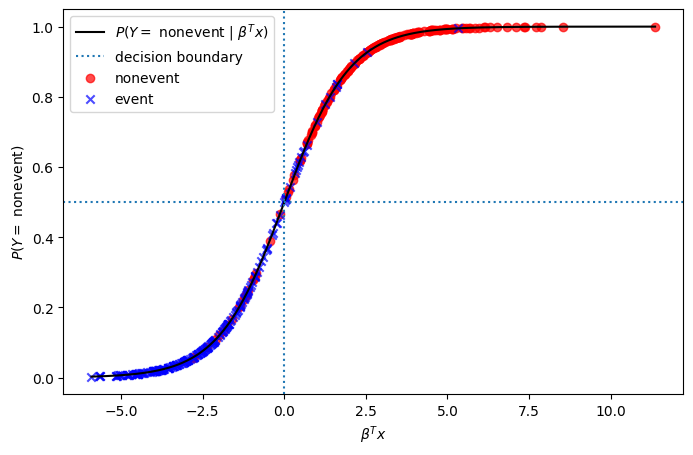

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_sigmoid(
    ax=ax,
    model=ev_ne_log_model,
    X_train=X_train_ev_ne_pca,
    y_train=y2_train,
    target_label="nonevent",
    inverse_label="event",
    title=None
)
plt.savefig(output_dir / 'logReg_loglog_pca_class2.png')

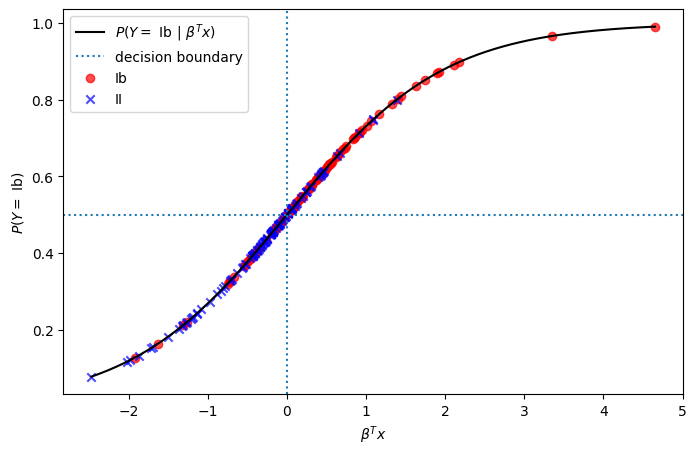

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_sigmoid(
    ax=ax,
    model=event_log_model,
    X_train=X_train_events_pca,
    y_train=y_train_events,
    target_label="Ib",
    inverse_label="II",
    title=None
)
plt.savefig(output_dir / 'logReg_loglog_pca_class4.png')

## Predicting on the test data

In [52]:
y_test_final_pred = ev_ne_log_model.predict(X_test_final_ev_ne_pca)
y_test_final_proba = ev_ne_log_model.predict_proba(X_test_final_ev_ne_pca)


y_test_final_ev_pred = event_log_model.predict(X_test_final_events_pca)

## Combining the predictions

In [53]:
#Use event prediction to fill the event type for samples predicted as event
class_4_pred = np.where(y_test_final_pred == 'event', y_test_final_ev_pred, 'nonevent')
#Combining the predictions into a dataframe for submission
classes = list(ev_ne_log_model.classes_)
submission_df = pd.DataFrame({
    'id': pd.read_csv(data_dir / 'test.csv')['id'],
    'class4': class_4_pred,
    'p': y_test_final_proba[:, classes.index('event')]
})
submission_df


,id,class4,p
0,450,II,0.682229
1,451,II,0.930708
2,452,nonevent,0.014986
3,453,nonevent,0.403946
4,454,Ib,0.864796
...,...,...,...
960,1410,nonevent,0.323576
961,1411,nonevent,0.056965
962,1412,II,0.892718
963,1413,nonevent,0.087021


## Saving the output

In [54]:
submission_df.to_csv(output_dir / 'submission_loglog_pca.csv', index=False)

In [55]:
submission_df.class4.value_counts()

class4
nonevent    507
II          229
Ib          229
Name: count, dtype: int64